In [71]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {str(project_root)}")
print(f"Current sys.path: {sys.path}")

import cktgen

Project root added to sys.path: c:\quack_pot\science\cktgen
Current sys.path: ['c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'c:\\quack_pot\\science\\cktgen', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\python313.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0', 'c:\\quack_pot\\science\\cktgen\\.notebooks', '', 'c:\\quack_pot\\science\\cktgen\\.notebooks\\Lib\\site-pack

In [72]:
GATE_INPUTS: list[list[float]] = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
GATE_OUTPUTS: list[list[float]] = [[0.0], [1.0], [1.0], [0.0]]

assert len(GATE_INPUTS) == len(GATE_OUTPUTS), "Inputs and outputs do not match in length."
assert len(GATE_INPUTS) > 0, "No gate data available for training."

standard_neural_dag: cktgen.models.StandardNeuralDAG = cktgen.models.StandardNeuralDAG(cktgen.models.StandardNeuralDAGCreateInfo(
    input_node_count=len(GATE_INPUTS[0]),
    hidden_node_count=5,
    output_node_count=len(GATE_OUTPUTS[0]),
))

gated_neural_dag: cktgen.models.GatedNeuralDAG = cktgen.models.GatedNeuralDAG(cktgen.models.GatedNeuralDAGCreateInfo(
    input_node_count=len(GATE_INPUTS[0]),
    hidden_node_count=5,
    output_node_count=len(GATE_OUTPUTS[0]),
))

nand_grid_dag: cktgen.models.NandGridDAG = cktgen.models.NandGridDAG(cktgen.models.NandGridDAGCreateInfo(
    input_node_count=len(GATE_INPUTS[0]),
    hidden_node_count=5,
    output_node_count=len(GATE_OUTPUTS[0]),
))

In [ ]:
standard_neural_dag.train(cktgen.models.StandardNeuralDAGTrainInfo(
    input_data=GATE_INPUTS,
    output_data=GATE_OUTPUTS,
    epochs=10000,
    epoch_print_cadence=1000,
    learning_rate=0.05,
    lambda_edges=3e-2,
    lambda_nodes=5e-2,
    node_strength_sharpness=60.0,
))

gated_neural_dag.train(cktgen.models.GatedNeuralDAGTrainInfo(
    input_data=GATE_INPUTS,
    output_data=GATE_OUTPUTS,
    epochs=10000,
    epoch_print_cadence=1000,
    learning_rate=0.05,
    lambda_edges=5e-3,
    lambda_discrete=1e-6,
))

nand_grid_dag.train(cktgen.models.NandGridDAGTrainInfo(
    input_data=GATE_INPUTS,
    output_data=GATE_OUTPUTS,
    epochs=10000,
    epoch_print_cadence=1000,
    learning_rate=0.05,
    lambda_edges=1e-3,
    lambda_discrete=5e-1,
))

NandGridDAG Training (Epoch = 0; Loss = 5.9478)
NandGridDAG Training (Epoch = 1000; Loss = 1.9612)
NandGridDAG Training (Epoch = 2000; Loss = 2.7127)
NandGridDAG Training (Epoch = 3000; Loss = 3.4639)
NandGridDAG Training (Epoch = 4000; Loss = 4.2137)
NandGridDAG Training (Epoch = 5000; Loss = 4.9617)
NandGridDAG Training (Epoch = 6000; Loss = 5.7076)
NandGridDAG Training (Epoch = 7000; Loss = 6.4514)
NandGridDAG Training (Epoch = 8000; Loss = 7.1928)
NandGridDAG Training (Epoch = 9000; Loss = 7.9317)


In [74]:
standard_neural_dag_accuracy: float = 0.0
gated_neural_dag_accuracy: float = 0.0
nand_grid_dag_accuracy: float = 0.0

for x, y in zip(GATE_INPUTS, GATE_OUTPUTS):
    standard_neural_dag_output: list[float] = standard_neural_dag.evaluate(x)
    gated_neural_dag_output: list[float] = gated_neural_dag.evaluate(x)
    nand_grid_dag_output: list[float] = nand_grid_dag.evaluate(x)

    for true_val, pred_val in zip(y, standard_neural_dag_output):
        if true_val == float(round(pred_val)):
            standard_neural_dag_accuracy += 1.0

    for true_val, pred_val in zip(y, gated_neural_dag_output):
        if true_val == float(round(pred_val)):
            gated_neural_dag_accuracy += 1.0

    for true_val, pred_val in zip(y, nand_grid_dag_output):
        if true_val == float(round(pred_val)):
            nand_grid_dag_accuracy += 1.0

standard_neural_dag_accuracy *= 100.0 / len(GATE_OUTPUTS)
gated_neural_dag_accuracy *= 100.0 / len(GATE_OUTPUTS)
nand_grid_dag_accuracy *= 100.0 / len(GATE_OUTPUTS)

print(f"StandardNeuralDAG Accuracy = {standard_neural_dag_accuracy:.2f}%")
print(f"GatedNeuralDAG Accuracy = {gated_neural_dag_accuracy:.2f}%")
print(f"NandGridDAG Accuracy = {nand_grid_dag_accuracy:.2f}%")

StandardNeuralDAG Accuracy = 50.00%
GatedNeuralDAG Accuracy = 50.00%
NandGridDAG Accuracy = 75.00%


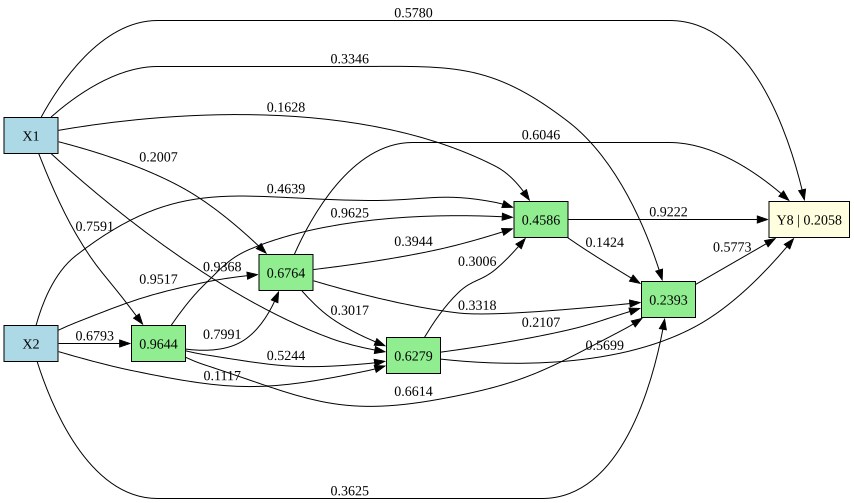

In [75]:
standard_neural_dag.extractDAG(edge_prune_threshold=0.1).renderGraph("StandardNeuralDAG")

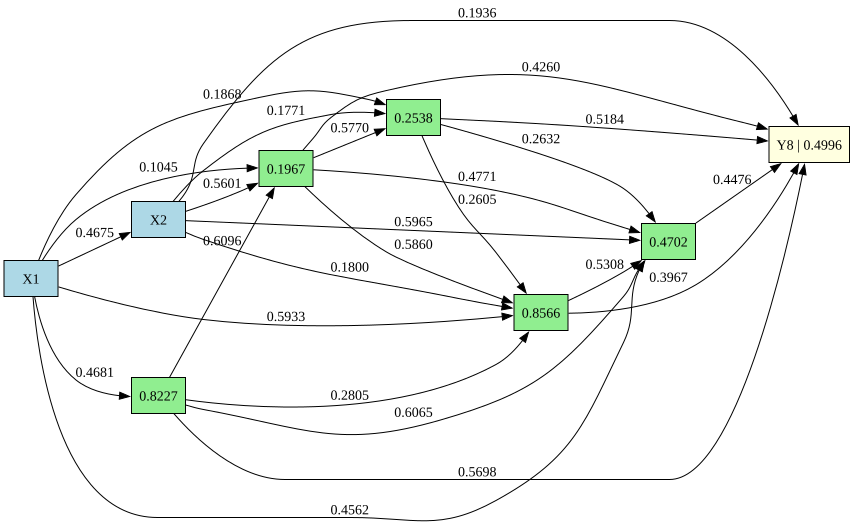

In [76]:
gated_neural_dag.extractDAG(edge_prune_threshold=0.1).renderGraph("GatedNeuralDAG")

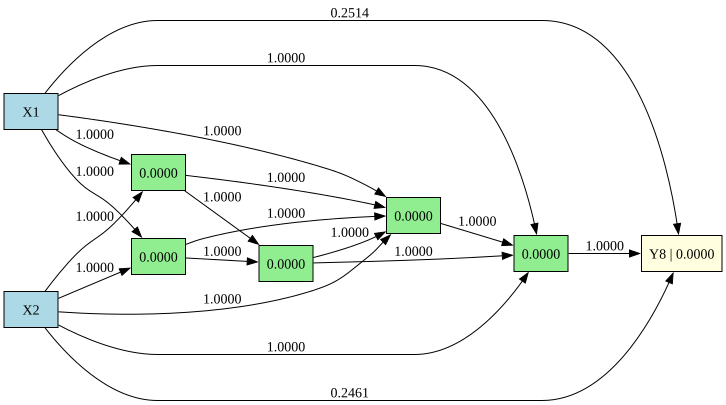

In [77]:
nand_grid_dag.extractDAG(edge_prune_threshold=0.1).renderGraph("NandGridDAG")